In [1]:
import pandas as pd 
data = pd.read_csv("synthetic_bMP_1000.csv")
data.head()

,%C,%N,%O,%S,%H,BMP_mean
0,42.883545,41.141028,1.744688,49.966001,0.258974,320.601166
1,40.877932,45.854155,1.836708,36.972577,0.423709,305.843704
2,40.248737,40.242392,1.432907,27.557299,0.000000,265.763992
3,39.977416,38.741028,1.488454,34.112728,0.009098,270.821118
4,45.542510,40.900876,1.298862,30.743091,0.193177,287.508136


In [2]:
X = data.drop(columns=["BMP_mean"] , axis= 1)
Y = data["BMP_mean"]


Training samples: 800
Testing samples: 200
Train R^2: 0.9977
Test R^2 (20% holdout): 0.9739
Test MAE: 3.28
Test RMSE: 4.41


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

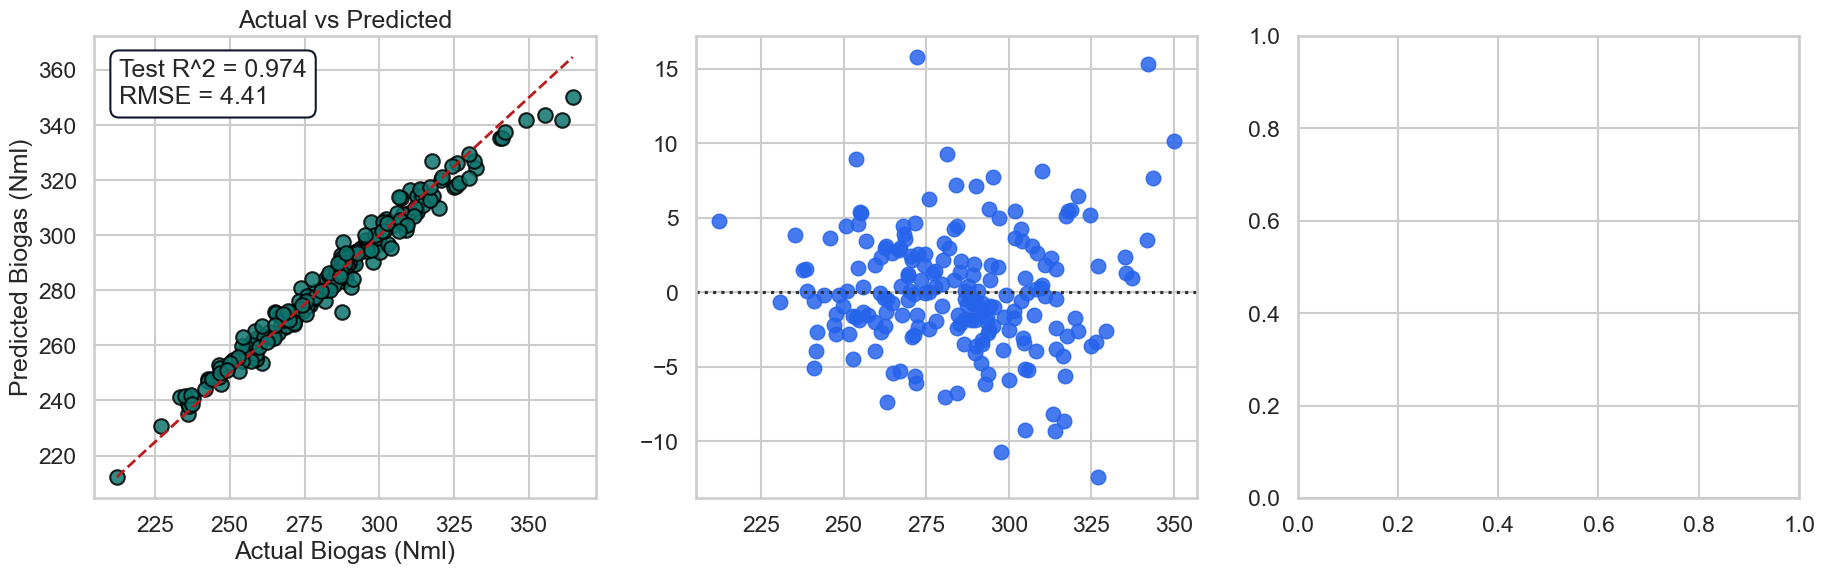

In [3]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")


X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
 )

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2 (20% holdout): {test_r2:.4f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

residuals = y_test - y_test_pred
axis_min = min(y_test.min(), y_test_pred.min())
axis_max = max(y_test.max(), y_test_pred.max())

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(y_test, y_test_pred, s=110, color="#0f766e", edgecolor="black", alpha=0.85)
axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "--", color="#b91c1c", linewidth=2)
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Biogas (Nml)")
axes[0].set_ylabel("Predicted Biogas (Nml)")
axes[0].text(
    0.05, 0.95,
    f"Test R^2 = {test_r2:.3f}\nRMSE = {test_rmse:.2f}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#0f172a")
)

sns.residplot(
    x=y_test_pred,
    y=residuals,
    lowess=True,
    scatter_kws={"s": 110, "alpha": 0.85, "color": "#2563eb"},
    line_kws={"color": "#dc2626", "linewidth": 2},
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Residuals on Test Set")
axes[1].set_xlabel("Predicted Biogas (Nml)")
axes[1].set_ylabel("Residuals")

importances = model.feature_importances_
sorted_idx = importances.argsort()[::-1]
axes[2].bar(
    [feature_names[index] for index in sorted_idx],
    importances[sorted_idx],
    color=sns.color_palette("crest", n_colors=len(feature_names)),
)
axes[2].set_title("Feature Importance")
axes[2].set_xlabel("Feature")
axes[2].set_ylabel("Importance Score")
axes[2].tick_params(axis="x", rotation=35)

fig.suptitle("XGBoost Performance on Biogas Prediction", fontsize=20, y=1.03)
fig.tight_layout()
plt.show()

5-Fold Cross-Validation R^2 Scores:
Fold 1: -0.1049
Fold 2: -0.8451
Fold 3: -0.0690
Fold 4: -0.0088
Fold 5: 0.1405
Mean CV R^2: -0.1775
Std CV R^2: 0.3442


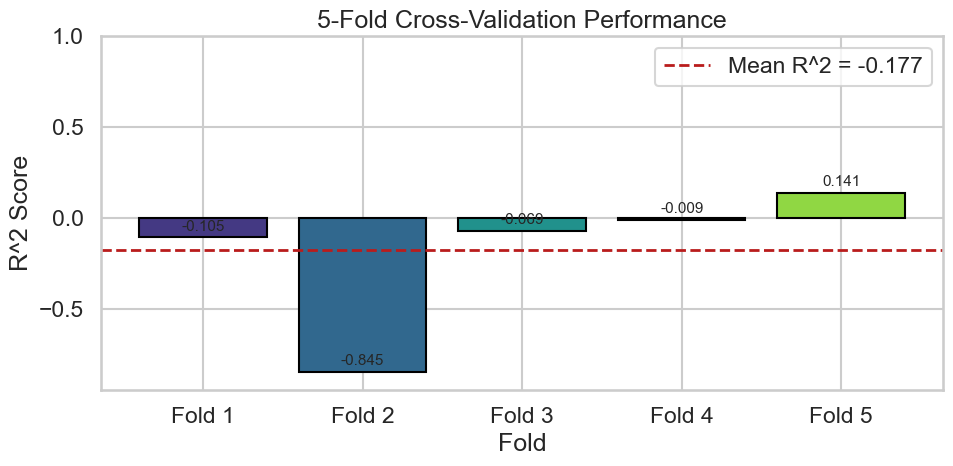

In [6]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

cv_r2_scores = cross_val_score(cv_model, X, Y, cv=cv, scoring="r2")

print("5-Fold Cross-Validation R^2 Scores:")
for fold_index, fold_score in enumerate(cv_r2_scores, start=1):
    print(f"Fold {fold_index}: {fold_score:.4f}")

print(f"Mean CV R^2: {cv_r2_scores.mean():.4f}")
print(f"Std CV R^2: {cv_r2_scores.std():.4f}")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    [f"Fold {index}" for index in range(1, len(cv_r2_scores) + 1)],
    cv_r2_scores,
    color=sns.color_palette("viridis", n_colors=len(cv_r2_scores)),
    edgecolor="black",
)
plt.axhline(cv_r2_scores.mean(), color="#b91c1c", linestyle="--", linewidth=2, label=f"Mean R^2 = {cv_r2_scores.mean():.3f}")
plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Fold")
plt.ylabel("R^2 Score")
plt.ylim(min(cv_r2_scores.min() - 0.1, 0), max(cv_r2_scores.max() + 0.1, 1))

for bar, score in zip(bars, cv_r2_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.legend()
plt.tight_layout()
plt.show()